# Lab:  Nonlinear Least Squares for Modeling Materials

Nonlinear least squares (NLLS) is a widely-used method for modeling data.  In NLLS, we wish to fit a model of the form,

     yhat = g(x,w)
     
where `w` is a vector of paramters and `x` is the vector of predictors.  We find `w` by minimizing a least-squares function

     f(w) = \sum_i (y_i - g(x_i,w))^2
     
where the summation is over training samples `(x_i,y_i)`.  This is similar to linear least-squares, but the function `g(x,w)` may not be linear in `w`.  In general, this optimization has no closed-form expression.  So numerical optimization must be used.  

In this lab, we will implement gradient descent on NLLS in a problem of physical modeling of materials.  Specifically, we will estimate parameters for expansion of copper as a function of temperature using a real dataset.  In doing this lab, you will learn to:
* Set up a nonlinear least squares as an unconstrained optimization function
* Compute initial parameter estimates for a simple rational model
* Compute the gradients of the least squares objective
* Implement gradient descent for minimizing the objective
* Implement momentum gradient descent
* Visualize the convergence of the algorithm

We first import some key packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression

## Load the Data

The NIST agency has an excellent [nonlinear regression website](https://www.itl.nist.gov/div898/strd/nls/nls_main.shtml) that has several datasets for nonlinear regression problems.  In this lab, we will use the data from a NIST study involving the thermal expansion of copper. The response variable is the coefficient of thermal expansion, and the predictor variable is temperature in degrees kelvin.  

> Hahn, T., NIST (1979), Copper Thermal Expansion Study.  (unpublished}

You can download the data as follows.

In [3]:
import pandas as pd
import urllib.request

url = 'https://www.itl.nist.gov/div898/strd/nls/data/LINKS/DATA/Hahn1.dat'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response:
    data = response.read().decode('utf-8')

# Now read into pandas
from io import StringIO
df = pd.read_csv(StringIO(data), skiprows=60, sep=' ', skipinitialspace=True,
                 names=['y0','x0','dummy'])
print(df.head())


      y0     x0  dummy
0  0.591  24.41    NaN
1  1.547  34.82    NaN
2  2.902  44.09    NaN
3  2.894  45.07    NaN
4  4.703  54.98    NaN


Extract the `x0` and `y0` into arrays.  Rescale, `x0` and `y0` to values between `0` and `1` by dividing `x0` and `y0` by the maximum value.  Store the scaled values in vectors `x` and `y`.  The rescaling will help with the conditioning of the fitting.  Plot, `y` vs. `x`.

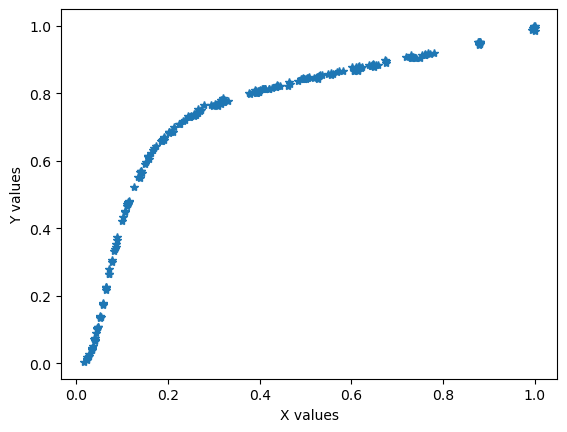

In [4]:
# TODO
x0 = df['x0'].values
y0 = df['y0'].values
x = x0/np.max(x0)
y = y0/np.max(y0)
plt.plot(x, y, '*')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

To make the problem a little more challenging, we will add some noise.  Add random Gaussian noise with mean 0 and std. dev = 0.02 to `y`.  Store the noisy results in `yn`. You can use the `np.random.normal()` function to add Gaussian noise. Plot `yn` vs. `x`.

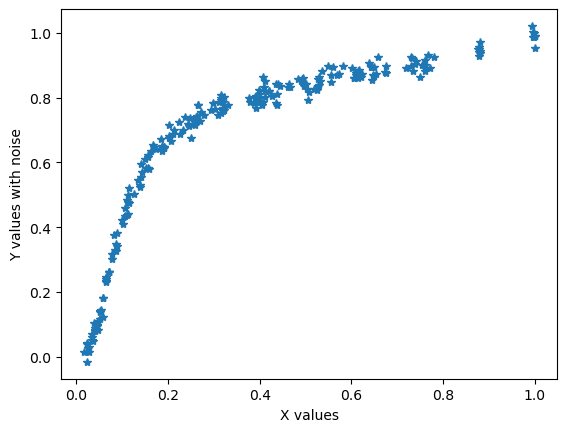

In [5]:
# TODO
yn = y + np.random.normal(0, 0.02, size=y.shape)
plt.plot(x, yn, '*')
plt.xlabel('X values')
plt.ylabel('Y values with noise')
plt.show()

Split the data `(x,yn)` into training and test.  Let `xtr,ytr` be training data and `xts,yts` be the test data.  You can use the `train_test_split` function.  Set `test_size=0.33` so that 1/3 of the samples are held out for test.

In [6]:
from sklearn.model_selection import train_test_split

# TODO
xtr, xts, ytr, yts = train_test_split(x, yn, test_size=0.33, random_state=42)

## Initial Fit for a Rational Model

The [NIST website](https://www.itl.nist.gov/div898/strd/nls/data/hahn1.shtml) suggests using a *rational* model of the form,

      yhat = (a[0] + a[1]*x + ... + a[d]*x^d)/(1 + b[0]*x + ... + b[d-1]*x^d)
      
with `d=3`.  The model parameters are `w = [a[0],...,a[d],b[0],...,b[d-1]]` so there are `2d+1` parameters total.    Complete the function below that takes vectors `w` and `x` and predicts a set of values `yhat` using the above model.
   

In [7]:
def predict(w,x):

    # Get the length
    d = (len(w)-1)//2

    # TODO.  Extract a and b from w
    a = w[:d+1]
    b = w[d+1:]

    b_with_1 = np.concatenate(([1], b))
    # TODO.  Compute yhat.  You may use the np.polyval function
    # But, remember you must flip the order the a and b
    yhat = np.polyval(a[::-1], x) / np.polyval(b_with_1[::-1], x)
    return yhat

When we fit with a nonlinear model, most methods only get convergence to a local minima.  So, you need a good initial condition.  For a rational model, one way to get is to realize that if:


    y ~= (a[0] + a[1]*x + ... + a[d]*x^d)/(1 + b[0]*x + ... + b[d-1]*x^d)
    
Then:

    y ~= a[0] + a[1]*x + ... + a[d]*x^d - b[0]*x*y + ... - b[d-1]*x^d*y.
    
So, we can solve for the the parameters `w = [a,b]` from linear regression of the predictors,

    Z[i,:] = [ x[i], ... , x[i]**d, y[i]*x[i], ... , y[i}*x[i]**d ]

In [8]:
d = 3

# TODO.  Create the transformed feature matrix

Z = np.column_stack([xtr**i for i in range(1, d+1)] + [ytr * xtr**i for i in range(1, d+1)])
# np.column_stack converts each (N,) into (N,1) and Concatenates them horizontally

# TODO.  Fit with parameters with linear regression
regr = LinearRegression()
regr.fit(Z, ytr)

# TODO
# Extract the parameters from regr.coef_ and regr.intercept_ and store the parameter vector in winit
winit = np.concatenate(([regr.intercept_], regr.coef_))

Now plot the predicted values of the `yhat` vs. `x` using your estimated parameter `winit` for 1000 values `x` in `[0,1]`.  On the same plot, plot `yts` vs. `xts`.  You will see that you get a horrible fit.

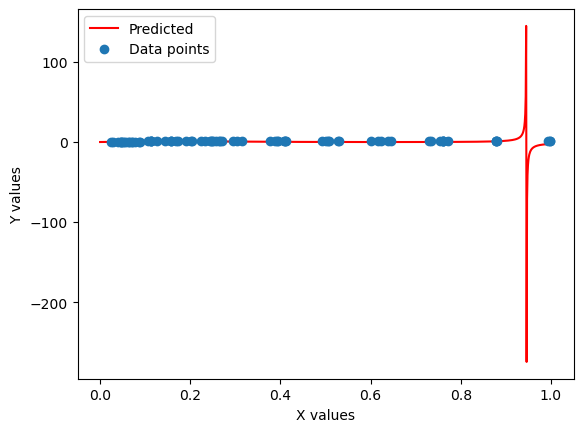

In [9]:
# TODO
xp = np.linspace(0, 1, 1000)
yhat = predict(winit, xp)
plt.plot(xp, yhat, color='red', label='Predicted')
plt.plot(xts, yts, 'o', label='Data points')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.show()

The reason the previous fit is poor is that the denominator in `yhat` goes close to zero.   To avoid this problem, we can use Ridge regression, to try to keep the parameters close to zero.  Re-run the fit above with `Ridge` with `alpha = 1e-3`. You should see you get a reasonable, but not perfect fit.

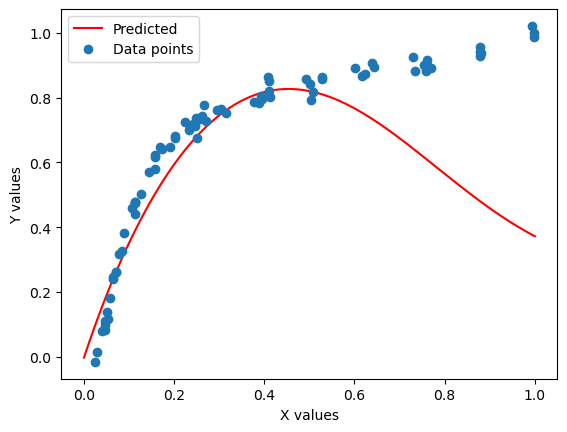

In [10]:
# TODO.  Fit with parameters with linear regression
regr = Ridge(alpha=1e-3)
regr.fit(Z, ytr)

# TODO
# Extract the parameters from regr.coef_ and regr.intercept_
winit = np.concatenate(([regr.intercept_], regr.coef_))

# TODO
# Plot the results as above.
xp = np.linspace(0, 1, 1000)
yhat = predict(winit, xp)
plt.plot(xp, yhat, color='red', label='Predicted')
plt.plot(xts, yts, 'o', label='Data points')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.show()

## Creating a Loss Function

We can now use gradient descent to improve our initial estimate.  Complete the following function to compute

    f(w) = 0.5*\sum_i (y[i] - yhat[i])^2
    
and `fgrad`, the gradient of `f(w)`.

In [11]:
def feval(w,x,y):


    # TODO.  Parse w
    d = (len(w)-1)//2
    a = w[:d+1]
    b = w[d+1:]

    # TODO.  Znum[i,j] = x[i]**j
    Znum = np.column_stack([x**i for i in range(d+1)])

    # TODO.  Zden[i,j] = x[i]**(j+1)
    Zden = np.column_stack([x**(i+1) for i in range(d)])

    # TODO.  Compute yhat
    # Compute the numerator and denominator
    num  = Znum @ a        
    den  = 1 + Zden @ b       
    yhat = num / den

    # TODO.  Compute loss
    
    f = 0.5 * np.sum((y - yhat)**2)

    # TODO.  Compute gradients
    grad_a = -Znum.T @ ((y-yhat) / den)

    grad_b = Zden.T @ ((y-yhat) * yhat / den)

    fgrad = np.concatenate([grad_a, grad_b])
    
    return f, fgrad


Test the gradient function:
* Take `w0=winit` and compute `f0,fgrad0 = feval(w0,xtr,ytr)`
* Take `w1` very close to `w0` and compute `f1,fgrad1 = feval(w1,xtr,ytr)`
* Verify that `f1-f0` is close to the predicted value based on the gradient.

In [12]:
# TODO
w0 = winit
f0, fgrad0 = feval(w0, xtr, ytr)
eps = 1e-5
dw = np.zeros_like(w0)
# making a small change in the first parameter
dw[0] = eps
f1, _ = feval(w0 + dw, xtr, ytr)
fd_grad = (f1 - f0) / eps
print(f'Analytic grad[0]: {fgrad0[0]:.6f}')
print(f'Finite-diff grad[0]: {fd_grad:.6f}')

Analytic grad[0]: -10.952467
Finite-diff grad[0]: -10.951747


## Implement gradient descent

We will now try to minimize the loss function with gradient descent.  Using the function `feval` defined above, implement gradient descent.  Run gradient descent with a step size of `alpha=1e-6` starting at `w=winit`.  Run it for `nit=10000` iterations.  Compute `fgd[it]`= the objective function on iteration `it`.  Plot `fgd[it]` vs. `it`.  

You should see that the training loss decreases, but it still hasn't converged after 10000 iterations.

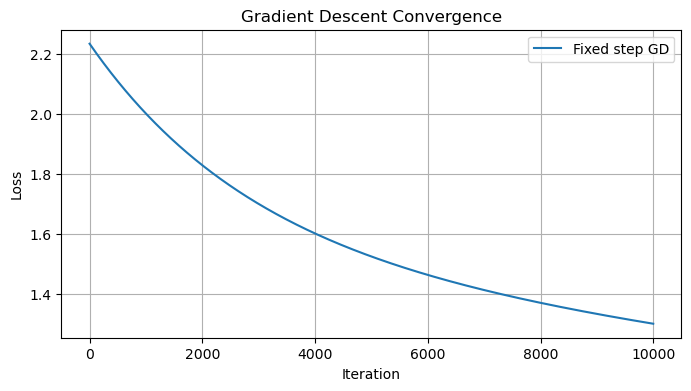

Final loss (fixed step): 1.301429


In [13]:
# TODO
nit = 10000
step = 1e-6
w_gd = winit.copy()
fgd = np.zeros(nit)

for it in range(nit):
    f, fgrad = feval(w_gd, xtr, ytr)
    fgd[it] = f
    w_gd = w_gd - step * fgrad

plt.figure(figsize=(8, 4))
plt.plot(fgd, label='Fixed step GD')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.grid(True)
plt.show()
print(f'Final loss (fixed step): {fgd[-1]:.6f}')


Now, try to get a faster convergence with adaptive step-size using the Armijo rule. Implement the gradient descent with adaptive step size.  Let `fadapt[it]` be the loss function on iteration `it`.  Plot `fadapt[it]` and `fgd[it]` vs. `it` on the same graph.  You should see a slight improvement, but not much.

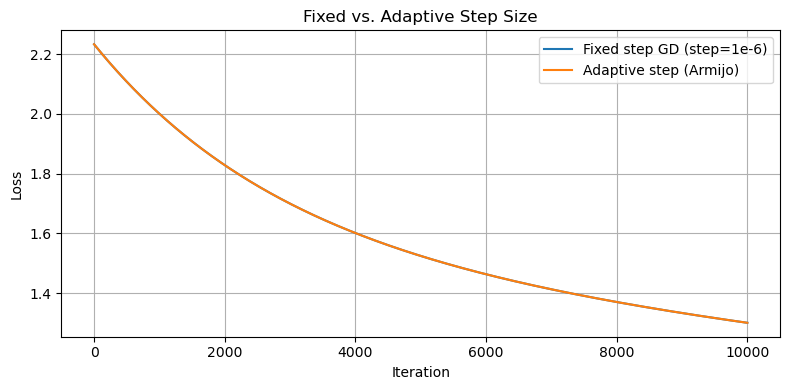

Final loss (adaptive): 1.301429


In [19]:
# TODO
nit = 10000
step = 1e-6  # Initial step
c_armijo = 1e-4 

w_adapt = winit.copy()
fadapt = np.zeros(nit)

for it in range(nit):
    f, fgrad = feval(w_adapt, xtr, ytr)
    fadapt[it] = f

    # Armijo backtracking line search
    alpha = step
    slope = np.dot(fgrad, fgrad)   # ||grad||^2

    while True:
        w_try = w_adapt - alpha * fgrad
        f_try, _ = feval(w_try, xtr, ytr)

        if f_try <= f - c_armijo * alpha * slope:
            break

        alpha *= 0.5   # shrink step size

    w_adapt = w_try

plt.figure(figsize=(8, 4))
plt.plot(fgd,    label='Fixed step GD (step=1e-6)')
plt.plot(fadapt, label='Adaptive step (Armijo)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Fixed vs. Adaptive Step Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Final loss (adaptive): {fadapt[-1]:.6f}')


Using he final estimate for `w` from the adaptive step-size plot the predicted values of the `yhat` vs. `x` usfor 1000 values `x` in `[0,1]`.  On the same plot, plot `yhat` vs. `x` for the initial parameter `w=winit`.  Also, plot `yts` vs. `xts`.  You should see that gradient descent was able to improve the estimat slightly, although the initial estimate was not too bad.

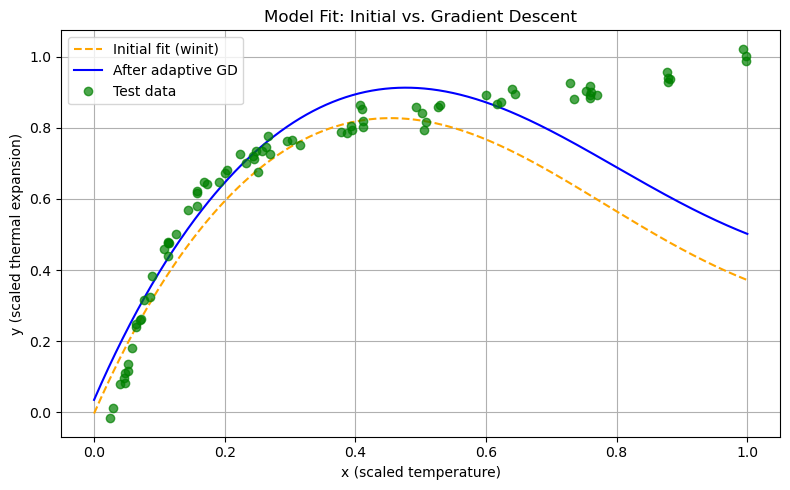

In [15]:
# TODO
xp = np.linspace(0, 1, 1000)

yhat_init  = predict(winit,   xp)
yhat_final = predict(w_adapt, xp)

plt.figure(figsize=(8, 5))
plt.plot(xp, yhat_init,  '--', color='orange', label='Initial fit (winit)')
plt.plot(xp, yhat_final, '-',  color='blue',   label='After adaptive GD')
plt.plot(xts, yts, 'o',        color='green',  label='Test data', alpha=0.7)
plt.xlabel('x (scaled temperature)')
plt.ylabel('y (scaled thermal expansion)')
plt.title('Model Fit: Initial vs. Gradient Descent')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Momentum Gradient Descent

This section is optinal.

One way to improve gradient descent is to use *momentum*.  In momentum gradient descent, the update rule is:

    f, fgrad = feval(w,...)
    z = beta*z + fgrad
    w = w - step*z
    
This is similar to gradient descent, except that there is a second order term on the gradient.  Implement this algorithm with `beta = 0.99` and `step=1e-3`.   Compare the convergence of the loss function with gradient descent.  

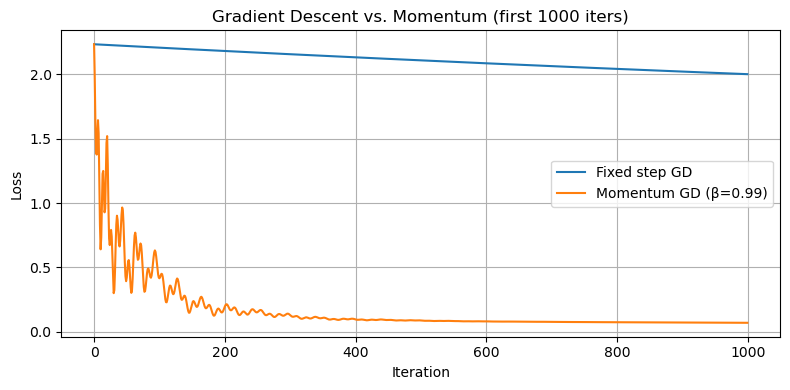

Final loss (momentum): 0.070103


In [16]:
# TODO
nit = 1000
step = 1e-3
beta = 0.99

w_mom = winit.copy()
z = np.zeros_like(w_mom)   # momentum accumulator
fmom = np.zeros(nit)

for it in range(nit):
    f, fgrad = feval(w_mom, xtr, ytr)
    fmom[it] = f
    z = beta * z + fgrad      # accumulate momentum
    w_mom = w_mom - step * z  # update

plt.figure(figsize=(8, 4))
plt.plot(fgd[:nit], label='Fixed step GD')
plt.plot(fmom, label='Momentum GD (β=0.99)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Gradient Descent vs. Momentum (first 1000 iters)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Final loss (momentum): {fmom[-1]:.6f}')

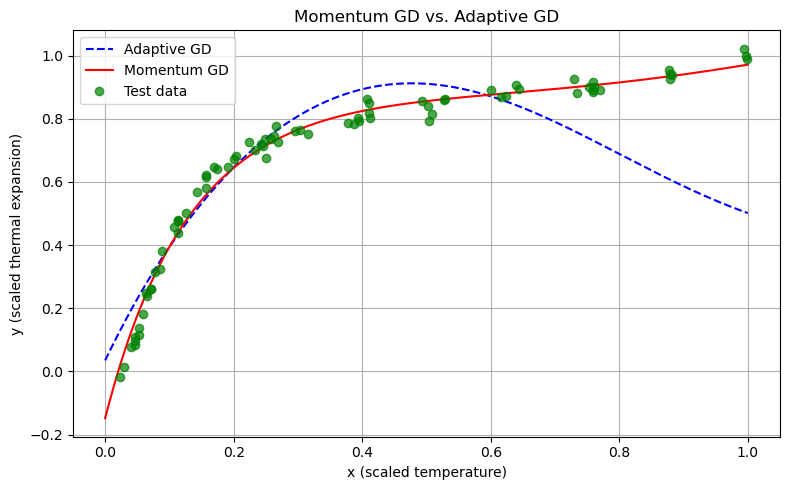

In [17]:
# TODO
# plot yhat vs. x
xp = np.linspace(0, 1, 1000)

yhat_mom   = predict(w_mom,   xp)
yhat_final = predict(w_adapt, xp)

plt.figure(figsize=(8, 5))
plt.plot(xp, yhat_final, '--', color='blue',   label='Adaptive GD')
plt.plot(xp, yhat_mom,   '-',  color='red',    label='Momentum GD')
plt.plot(xts, yts, 'o',        color='green',  label='Test data', alpha=0.7)
plt.xlabel('x (scaled temperature)')
plt.ylabel('y (scaled thermal expansion)')
plt.title('Momentum GD vs. Adaptive GD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Beyond This Lab
In this lab, we have just touched at some of the ideas in optimization.  There are several other important algorithms that you can explore:
* [Levenberg-Marquardt](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm) method for non-linear least squares
* Newton's method
* More difficult non-linear least squares problems.